## DAVE Demo
- Compare Stable Diffusion 3 generation with DAVE!

### 1. Setup
Set `REPO` to your DAVE repo root, then import dependencies. The repo is expected to contain `diffusers/src` (the diffusers source to use as base) and `DAVE/` (the DAVE override files).

In [ ]:
import importlib.util
import sys
from pathlib import Path

import torch
from matplotlib import pyplot as plt

REPO = Path('.') #You need to fill this path
DAVE_DIR = REPO / 'diffusers-dave'
DIFFUSERS_SRC = REPO / 'diffusers' / 'src'

sys.path.insert(0, str(DIFFUSERS_SRC))

### 2. Load DAVE modules
Use `load_module` to load DAVE's transformer / pipeline files directly, then point the `diffusers` package at these implementations.

In [ ]:
def load_module(module_name, path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

dave_transformer_mod = load_module(
    'diffusers.models.transformers.transformer_sd3',
    DAVE_DIR / 'transformer_sd3.py',
)

import diffusers.models.transformers as transformers_pkg
transformers_pkg.SD3Transformer2DModel = dave_transformer_mod.SD3Transformer2DModel

dave_pipeline_mod = load_module(
    'diffusers.pipelines.stable_diffusion_3.pipeline_stable_diffusion_3',
    DAVE_DIR / 'pipeline_stable_diffusion_3.py',
)
StableDiffusion3Pipeline = dave_pipeline_mod.StableDiffusion3Pipeline

### 3. Load the pipeline

In [ ]:
MODEL_ID = 'stabilityai/stable-diffusion-3-medium-diffusers'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

pipe = StableDiffusion3Pipeline.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)
pipe.set_progress_bar_config(disable=False)

### 4. Generate and compare
Generate the baseline and DAVE results from the same seed.

In [4]:
PROMPT = 'A photo of a squirrel in a tuxedo with a sign that says “Hello”'
SEED = 0
NUM_STEPS = 28
GUIDANCE = 7.0

# DAVE_SCALE: scales DC (the feature mean over tokens). 1.0=no change, 0.5=weaken, 0.0=remove.
# DAVE_STEPS: denoising step indices where DAVE is applied (not scheduler timestep values).
DAVE_SCALE = 0.5
DAVE_STEPS = [0, 1, 2, 3]

In [ ]:
common_kwargs = dict(
    prompt=PROMPT,
    num_inference_steps=NUM_STEPS,
    guidance_scale=GUIDANCE,
)

baseline = pipe(
    **common_kwargs,
    generator=torch.Generator(device=DEVICE).manual_seed(SEED),
    use_dave=False,
).images[0]

dave = pipe(
    **common_kwargs,
    generator=torch.Generator(device=DEVICE).manual_seed(SEED),
    use_dave=True,
    dave_steps=DAVE_STEPS,
    dave_scale=DAVE_SCALE,
).images[0]

100%|██████████| 28/28 [00:01<00:00, 16.21it/s]


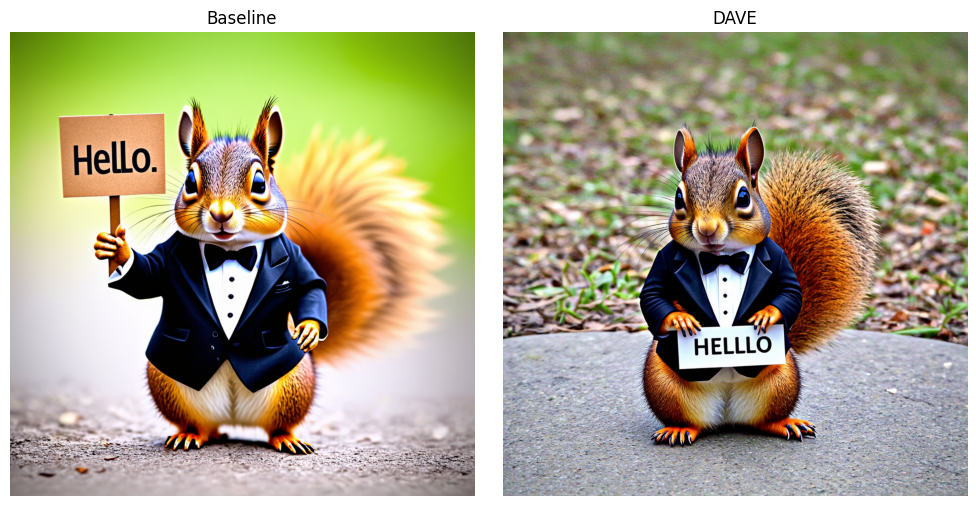

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(baseline)
ax1.set_title('Baseline')
ax1.axis('off')
ax2.imshow(dave)
ax2.set_title('DAVE')
ax2.axis('off')
plt.tight_layout()
plt.show()